# [PBT] 화장품 이커머스 ㅣ 03. 분석 대상 테이블 생성

## 이 노트북이 하는 일

원본은 **1행이 행동 하나**다. 한 사람이 수십 행을 남긴다.
그러나 분석 질문은 고객 단위이므로, 로지스틱 회귀에 넣으려면 **1행이 고객 하나**여야 한다.

그래서 행동 단위의 행을 고객 단위로 바꾸는 변환 작업을 아래 3단계에 걸쳐서 행한다.

| 단계 | 내용 | 담당 |
|---|---|---|
| **①** | **대상 고객과 t₀ 확정** | 배지환 ← **이 노트북** |
| ② | 목표변수 Y 생성 | 이슬기 |
| ③ | 설명변수 X — 조회 변수 4종 | 배지환 |

②와 ③은 서로 독립이지만 **둘 다 ①의 산출물을 필요로 한다.**
그래서 ①을 먼저 끝내고 파일로 공유한 뒤 병렬로 진행한다.

## #01. 준비작업

### 1. 라이브러리 참조

In [2]:
import os, sys

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
os.chdir(BASE)             # 폰트 경로가 상대경로라 여기서 실행해야 한다
sys.path.insert(0, BASE)

from datetime import timedelta as td
from pandas import read_parquet, set_option
from helpers import *

set_option("display.max_columns", 50)

### 2. 데이터 불러오기

> `category_id`는 parquet에서 다시 읽으면 숫자로 풀리므로,
> **불러올 때마다** 재변환한다.

In [3]:

OUT = BASE + r"\output"

df = read_parquet(OUT + r"\01_qtcheck.parquet")
df = my_qtcheck.set_type(df, as_category=["category_id"])

<class 'pandas.DataFrame'>
RangeIndex: 8259159 entries, 0 to 8259158
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   event_time     datetime64[us]
 1   event_type     category      
 2   product_id     int32         
 3   category_id    category      
 4   category_code  category      
 5   brand          category      
 6   price          float64       
 7   user_id        int64         
 8   user_session   str           
dtypes: category(4), datetime64[us](1), float64(1), int32(1), int64(1), str(1)
memory usage: 615.3 MB


### 3. t₀ 경계 산출 — 뒤와 앞

t₀는 **양쪽 끝을 잘라낸다.** 자르는 이유가 서로 다르다.

#### 뒤 — 컷오프 (`관측 종료 − 7일`)

관측 종료 직전에 담은 건은 **7일을 다 지켜볼 수 없다.**
예를 들어 11월 28일에 담은 고객은 3일치만 관찰되고 나머지 4일을 볼 수 없다.

이를 Y=0으로 기록하면 **실제로는 5일 뒤에 샀을 수도 있는 사례를 미구매로 처리**하는 것이 된다.
그러면 모델은 "늦게 담으면 사지 않는다"는 패턴을 학습하는데,
이는 고객의 행동이 아니라 **데이터 수집을 멈춘 시점 때문에 생긴 인위적 결과**다.

#### 앞 — 번인 (`관측 시작일 + 10일`)

이 가게는 10월 1일에 문을 연 것이 아니라 **우리가 10월 1일에 관측을 시작했을 뿐이다.**
그래서 그 이전부터 이용하던 고객의 "관측상 최초 담기"가 초반에 한꺼번에 잡힌다.
일별 t₀ 인원이 평상시 2,500명 수준인데 10/02에는 21,424명이 몰렸고,
**관측 첫 7일에 전체 대상의 36.8%가 들어 있다.**

이 초반 집단은 조회는 많고 구매는 적다. 조회하고 담은 59,267명의 7일 내 구매율이 **4.90%** 로,
같은 조건의 평지 고객(21.20%)과 비교가 되지 않는다.
이들이 표본의 31%를 차지하면서 `has_prior_view`와 Y의 관계 **부호를 통째로 뒤집는다.**
(전체 집계 시 조회 없음 18.87% vs 조회 있음 13.60% → 번인 후 18.57% vs 21.20%)

경계는 **일별 t₀ 인원이 평상시 수준으로 내려오는 첫날**로 정했다. 10/11이다.
**목표변수를 보고 고르지 않았다**는 점이 중요하다. Y 안정화는 사후 확인으로만 사용했다.

> 두 경계 모두 **날짜를 손으로 적지 않고 데이터에서 산출한다.**
> 시간대를 UTC+3으로 보정하면서 관측 시작·종료 시각이 함께 옮겨졌고,
> 계획서의 "11/23 이후 제외"는 UTC 기준 값이라 그대로 쓸 수 없다.
> 
> 근거에 대한 검증은 이후 07번 노트북에서 서술한다.

In [4]:
BURNIN = df["event_time"].min().normalize() + td(days=10)   # 관측 시작일 + 10일
CUTOFF = df["event_time"].max() - td(days=7)

print("관측 시작 :", df["event_time"].min())
print("관측 종료 :", df["event_time"].max())
print("번인 경계 :", BURNIN)
print("t0 컷오프 :", CUTOFF)

관측 시작 : 2019-10-01 03:00:00
관측 종료 : 2019-12-01 02:59:58
번인 경계 : 2019-10-11 00:00:00
t0 컷오프 : 2019-11-24 02:59:58


## #02. cart 이벤트 추출

### 1. 필요한 컬럼만 남긴다

`price`·`brand`·`category_id`를 **여기서 함께 들고 온다.**

`price`는 시간에 따라 변동한다. 나중에 별도의 상품 목록에서 병합하면 "임의 시점의 가격"이 된다.

우리가 필요한 것은 **해당 고객이 담을 때의 가격**이므로, t₀ 행에 적힌 값을 그대로 써야 한다.

In [5]:
COLS = ["user_id", "event_time", "product_id", "price", "brand", "category_id"]

carts = df.loc[df["event_type"] == "cart", COLS]

print(f"cart 이벤트    : {len(carts):,}행")
print(f"cart를 낸 고객 : {carts['user_id'].nunique():,}명")
carts.head()

cart 이벤트    : 2,490,795행
cart를 낸 고객 : 210,593명


,user_id,event_time,product_id,price,brand,category_id
0,463240011,2019-10-01 03:00:00,5773203,2.62,runail,1487580005134238553
1,463240011,2019-10-01 03:00:03,5773353,2.62,runail,1487580005134238553
2,429681830,2019-10-01 03:00:07,5881589,13.48,lovely,2151191071051219817
3,463240011,2019-10-01 03:00:07,5723490,2.62,runail,1487580005134238553
4,429681830,2019-10-01 03:00:15,5881449,0.56,lovely,1487580013522845895


## #03. t₀ 확정

### 1. 고객별 가장 이른 담기 시각

`groupby`로 최솟값을 구한다. 이 시각이 t₀다.

In [6]:
t0 = (carts.groupby("user_id")["event_time"]
            .min()
            .rename("t0")
            .reset_index())

print(f"고객 수 : {len(t0):,}")
t0.head()

고객 수 : 210,593


,user_id,t0
0,4103071,2019-10-22 00:05:31
1,5493470,2019-11-11 21:02:35
2,6217356,2019-11-22 15:39:43
3,8846226,2019-10-02 00:01:24
4,9794320,2019-10-01 09:03:28


### 2. t₀ 시각의 원본 행을 되찾아온다

위에서 구한 것은 **시각뿐**이다. "언제"는 알지만 "무엇을 담았는지"는 모른다.

그래서 t₀를 cart 테이블에 붙인 뒤, **`event_time`이 t₀와 같은 행만** 남긴다.
그 행에 `product_id`·`price`·`brand`·`category_id`가 함께 들어 있다.

In [7]:
first = carts.merge(t0, on="user_id")
first = first.loc[first["event_time"] == first["t0"]]

print(f"t0 시각의 cart 행 : {len(first):,}행")
print(f"고객 수           : {first['user_id'].nunique():,}명")
first.head()

t0 시각의 cart 행 : 210,860행
고객 수           : 210,593명


,user_id,event_time,product_id,price,brand,category_id,t0
0,463240011,2019-10-01 03:00:00,5773203,2.62,runail,1487580005134238553,2019-10-01 03:00:00
2,429681830,2019-10-01 03:00:07,5881589,13.48,lovely,2151191071051219817,2019-10-01 03:00:07
5,430174032,2019-10-01 03:00:16,5857269,2.62,runail,1487580005134238553,2019-10-01 03:00:16
6,377667011,2019-10-01 03:00:19,5739055,4.75,kapous,1487580008246412266,2019-10-01 03:00:19
7,467916806,2019-10-01 03:00:24,5825598,0.56,NaN,1487580009445982239,2019-10-01 03:00:24


> 행 수가 고객 수보다 많다면, **같은 초에 여러 상품을 담은 고객**이 있다는 뜻이다.
> 그 처리는 `#05`에서 한다.

## #04. 제외 규칙 (1) — 관측 경계 밖에서 담은 고객

`#01-3`에서 산출한 두 경계를 적용한다. 뒤(컷오프)를 먼저, 앞(번인)을 나중에.

### 1. 컷오프 이후에 담은 고객


In [8]:
before_n = first["user_id"].nunique()

first = first.loc[first["t0"] <= CUTOFF]

after_n = first["user_id"].nunique()

print(f"제외 전 : {before_n:,}명")
print(f"제외 후 : {after_n:,}명")
print(f"제외    : {before_n - after_n:,}명 ({(before_n - after_n) / before_n:.2%})")

제외 전 : 210,593명
제외 후 : 190,925명
제외    : 19,668명 (9.34%)


### 2. 번인 이전에 담은 고객

관측 시작 직후에 몰려 들어온 구간을 잘라낸다.
기계를 처음 켜면 안정될 때까지 걸리는 시간의 측정값을 버리는 것과 같은 이치라
**번인(burn-in)** 이라고 부른다.


In [9]:
before_n = first["user_id"].nunique()

first = first.loc[first["t0"] >= BURNIN]

after_n = first["user_id"].nunique()

print(f"제외 전 : {before_n:,}명")
print(f"제외 후 : {after_n:,}명")
print(f"제외    : {before_n - after_n:,}명 ({(before_n - after_n) / before_n:.2%})")


제외 전 : 190,925명
제외 후 : 108,630명
제외    : 82,295명 (43.10%)


## #05. 제외 규칙 (2) — 같은 초에 서로 다른 상품을 담은 고객

목표변수가 **"담은 그 상품을 구매하였는가"**이므로, 대상 상품이 하나로 특정되어야 한다.
그런데 t₀가 초 단위로 같으면서 상품이 둘 이상이면 어느 것을 "그 상품"으로 볼지 정할 수 없다.

> **한 방문에서 여러 상품을 담은 경우는 여기에 해당하지 않는다.**
> 시각이 조금이라도 다르면 먼저 담은 것이 t₀이고, 그 하나만 사용한다.
> 같은 상품이 같은 초에 두 번 찍힌 경우는 01번 노트북의 중복 정리에서 이미 하나로 합쳐졌다.

### 1. 해당 고객 확인

In [10]:
n_prod = first.groupby("user_id")["product_id"].nunique()
multi   = n_prod[n_prod > 1].index

print(f"동시각 복수 상품 고객 : {len(multi):,}명 ({len(multi) / len(n_prod):.2%})")
print()
print("상품 수 분포")
print(n_prod.value_counts().sort_index().head(10).to_string())

동시각 복수 상품 고객 : 172명 (0.16%)

상품 수 분포
product_id
1    108458
2       164
3         6
4         1
8         1


### 2. 제외

In [11]:
target = first.loc[~first["user_id"].isin(multi)]

print(f"최종 대상 고객 : {target['user_id'].nunique():,}명")
print(f"테이블 행 수   : {len(target):,}행")

최종 대상 고객 : 108,458명
테이블 행 수   : 108,458행


## #06. 컬럼 정리

`event_time`은 t₀와 같은 값이므로 제거한다.

In [12]:
target = target[["user_id", "t0", "product_id", "price", "brand", "category_id"]]
target = target.reset_index(drop=True)

target.info()
target.head()

<class 'pandas.DataFrame'>
RangeIndex: 108458 entries, 0 to 108457
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   user_id      108458 non-null  int64         
 1   t0           108458 non-null  datetime64[us]
 2   product_id   108458 non-null  int32         
 3   price        108458 non-null  float64       
 4   brand        66322 non-null   category      
 5   category_id  108458 non-null  category      
dtypes: category(2), datetime64[us](1), float64(1), int32(1), int64(1)
memory usage: 3.3 MB


,user_id,t0,product_id,price,brand,category_id
0,543079411,2019-10-11 00:00:17,5591314,4.29,NaN,1487580005268456287
1,555391563,2019-10-11 00:01:47,5816172,5.24,grattol,1602943681873052386
2,385999154,2019-10-11 00:01:51,5753492,13.02,italwax,1487580013069861041
3,558950685,2019-10-11 00:02:04,5875777,2.05,NaN,2084144451428549153
4,558519615,2019-10-11 00:02:17,5810157,1.43,irisk,1487580009445982239


## #07. 검증

만든 테이블이 의도대로인지 확인한다. 하나라도 실패하면 다음 단계로 넘어가지 않는다.

### 1. 1행 = 1고객인가

In [13]:
print("행 수   :", format(len(target), ","))
print("고객 수 :", format(target["user_id"].nunique(), ","))
print("일치    :", len(target) == target["user_id"].nunique())

행 수   : 108,458
고객 수 : 108,458
일치    : True


### 2. t₀가 두 경계 안에 있는가


In [14]:
print("t0 최솟값 :", target["t0"].min())
print("t0 최댓값 :", target["t0"].max())
print()
print("번인 경계 :", BURNIN, " / 미달 :", (target["t0"] < BURNIN).sum())
print("컷오프    :", CUTOFF, " / 초과 :", (target["t0"] > CUTOFF).sum())


t0 최솟값 : 2019-10-11 00:00:17
t0 최댓값 : 2019-11-24 02:58:43

번인 경계 : 2019-10-11 00:00:00  / 미달 : 0
컷오프    : 2019-11-24 02:59:58  / 초과 : 0


### 3. 결측 확인

`brand`의 결측은 **정상이다.** 원본에서 41%대로 비어 있는 컬럼이며,
삭제하지 않고 '미상' 범주로 유지하기로 방침을 정해 두었다(처리는 ⑤ 전처리 단계).

`user_id`·`t0`·`product_id`·`price`·`category_id`에 결측이 있으면 안 된다.

In [15]:
my_qtcheck.check_missing_values(target)

,Missing Count,Missing Ratio (%)
user_id,0,0.000000
t0,0,0.000000
product_id,0,0.000000
price,0,0.000000
brand,42136,38.850062
category_id,0,0.000000


### 4. 무작위 3명 눈으로 확인

원본 로그에서 해당 고객의 cart 기록을 직접 뽑아,
테이블의 t₀·`product_id`·`price`가 실제 최초 담기 행과 일치하는지 본다.

In [16]:
sample_ids = target["user_id"].sample(3, random_state=3217).to_list()

for uid in sample_ids:
    print("=" * 70)
    print("user_id :", uid)
    print("[테이블]")
    print(target.loc[target["user_id"] == uid].to_string(index=False))
    print("[원본 로그의 cart 기록 — 시간순]")
    print(carts.loc[carts["user_id"] == uid]
               .sort_values("event_time")
               .head(5)
               .to_string(index=False))
    print()

user_id : 250311201
[테이블]
  user_id                  t0  product_id  price brand         category_id
250311201 2019-11-03 10:03:59     5671878   9.52   NaN 1487580006937789357
[원본 로그의 cart 기록 — 시간순]


  user_id          event_time  product_id  price  brand         category_id
250311201 2019-11-03 10:03:59     5671878   9.52    NaN 1487580006937789357
250311201 2019-11-03 10:05:02     5832261   7.14    NaN 1487580011283087468
250311201 2019-11-03 10:07:04        4967   2.41 runail 1487580008187692007
250311201 2019-11-03 10:07:27     5775528   4.44    NaN 1487580008187692007
250311201 2019-11-03 10:14:10     5759183   1.67  irisk 1487580010100293687

user_id : 565763975
[테이블]
  user_id                  t0  product_id  price brand         category_id
565763975 2019-10-30 15:34:21     5799891  19.03   NaN 1487580009051717646
[원본 로그의 cart 기록 — 시간순]
  user_id          event_time  product_id  price brand         category_id
565763975 2019-10-30 15:34:21     5799891  19.03   NaN 1487580009051717646

user_id : 560978725
[테이블]
  user_id                  t0  product_id  price brand         category_id
560978725 2019-10-16 22:00:27     5751383  10.32   uno 1487580005092295511
[원본 로그의 cart 기록 —

> 확인할 것 — 원본에서 **가장 위에 있는 cart 행**이 테이블의 t₀·상품과 같아야 한다.

## #08. 저장 및 공유

②(Y 생성)와 ③(X 파생)이 이 파일을 함께 사용한다.

### 저장 형식 — 여기서부터는 CSV

| 파일 | 규모 | 형식 | 이유 |
|---|---|---|---|
| `01_qtcheck.parquet` | 826만 행 | parquet | 엑셀 상한(1,048,576행) 초과. CSV로 두면 1GB에 가깝고, 읽을 때마다 날짜를 다시 파싱해야 한다 |
| **`02a_target.csv`** | **약 19만 행** | **CSV** | 10MB 남짓이라 CSV의 부담이 없다. **엑셀로 열어 눈으로 확인할 수 있다** |

분석 테이블은 20명 수기 대조처럼 직접 들여다볼 일이 많으므로 CSV가 유리하다.

In [17]:
target.to_csv(OUT + r"\02a_target.csv", index=False, encoding="utf-8-sig")
print("저장 완료 :", OUT + r"\02a_target.csv")
print(f"{len(target):,}행 × {target.shape[1]}열")

저장 완료 : .\output\02a_target.csv
108,458행 × 6열


> CSV는 타입을 보존하지 않으므로 날짜와 명목형을 다시 변환한다.
> `utf-8-sig`로 저장했으므로 엑셀에서 바로 열어도 한글이 깨지지 않는다.


## #9. [진단] 번인으로 빠지는 사람은 누구인가

번인은 표본의 43%를 덜어낸다. **무엇을 덜어내는지 확인하지 않고 버리면 안 된다.**

여기서 검증하는 가설은 이것이다 —
*"t₀가 이른 날짜에 찍힌 고객은 원래 담기 빈도가 높은 사람이 아닌가?"*
만약 그렇다면 번인은 활발한 고객을 체계적으로 덜어내는 셈이고, 그건 한계로 적어야 한다.

**판정 기준을 먼저 정해 두고 시작한다.** 첫 주 재담기율 ÷ 평지 재담기율이
1.3 이상이면 지지, 1.1 미만이면 기각, 그 사이면 보류.

> 이 진단은 `#04-2`의 번인을 **적용하기 전** 인구(190,925명)를 다시 만들어 쓴다.
> 빠질 사람들이 표에 남아 있어야 "무엇이 빠지는가"를 잴 수 있기 때문이다.


In [19]:
# ============================================================
# [진단] t₀ 코호트별 담기 빈도 확인
#   가설 : t₀가 이른 날짜에 찍힌 고객일수록 담기 빈도가 높은 사람이다
#   판정 : 첫 주 재담기율 / 평지 구간 재담기율 ≥ 1.3  → 지지
#                                              < 1.1  → 기각
#
#   ※ 이 진단은 일부러 **번인 적용 전** 인구를 쓴다.
#     "번인으로 무엇이 빠지는가"를 재는 것이므로 빠질 사람들이 표에 남아 있어야 한다.
# ============================================================
from pandas import read_parquet, DataFrame, Timedelta

PATH = OUT      # #01-2 에서 정한 경로를 그대로 쓴다

# ---------- #A. 로드 및 cart 이벤트 추출 ----------
log = read_parquet(PATH + r"\01_qtcheck.parquet",
                   columns=["user_id", "event_time", "event_type"])

CUTOFF = log["event_time"].max() - Timedelta(days=7)
print("CUTOFF      :", CUTOFF)

cart = log.loc[log["event_type"] == "cart", ["user_id", "event_time"]]
print("cart 이벤트 :", format(len(cart), ","))

CUTOFF      : 2019-11-24 02:59:58
cart 이벤트 : 2,490,795


In [20]:
# ---------- #B. 고객별 t₀ (03번과 동일 기준) ----------
t0 = cart.groupby("user_id")["event_time"].min().reset_index()
t0.columns = ["user_id", "t0"]
t0 = t0.loc[t0["t0"] <= CUTOFF]

print("대상 고객   :", format(len(t0), ","))     # 190,925 (번인 적용 전 기준. 번인 후 최종 대상은 108,458명)

대상 고객   : 190,925


In [21]:
# ---------- #C. t₀ 이후 7일 내 재담기 ----------
# 창을 7일로 고정하는 이유
#   총 cart 건수를 쓰면 t₀가 이를수록 남은 관측기간이 길어서
#   자동으로 건수가 많아진다(관측기간 교란).
#   컷오프 덕분에 모든 고객이 t₀ 이후 7일을 온전히 갖고 있으므로,
#   7일 고정 창을 쓰면 이 교란이 제거되고 순수 빈도만 남는다.

c  = cart.merge(t0, on="user_id")
hi = c["t0"] + Timedelta(days=7)
c  = c.loc[(c["event_time"] > c["t0"]) & (c["event_time"] <= hi)]

recart = c.groupby("user_id").size().reset_index()
recart.columns = ["user_id", "recart_cnt"]

d = t0.merge(recart, on="user_id", how="left")
d["recart_cnt"] = d["recart_cnt"].fillna(0).astype("int32")
d["recart_yn"]  = (d["recart_cnt"] > 0).astype("int8")
d["t0_date"]    = d["t0"].dt.date.astype(str)

print(d.head())

   user_id                  t0  recart_cnt  recart_yn     t0_date
0  4103071 2019-10-22 00:05:31           0          0  2019-10-22
1  5493470 2019-11-11 21:02:35           4          1  2019-11-11
2  6217356 2019-11-22 15:39:43           0          0  2019-11-22
3  8846226 2019-10-02 00:01:24          23          1  2019-10-02
4  9794320 2019-10-01 09:03:28          12          1  2019-10-01


In [22]:
# ---------- #D. t₀ 날짜별 집계 ----------
g = d.groupby("t0_date")
coh = DataFrame({
    "n"          : g.size(),
    "recart_rate": (g["recart_yn"].mean() * 100).round(2),
    "recart_mean": g["recart_cnt"].mean().round(2),
}).reset_index()

print(coh.head(16))
print("...")
print(coh.tail(10))

       t0_date      n  recart_rate  recart_mean
0   2019-10-01   6296        89.12         8.46
1   2019-10-02  21424        96.57         3.46
2   2019-10-03   5291        86.58         6.99
3   2019-10-04   2976        80.81         9.72
4   2019-10-05   2631        80.65         9.27
5   2019-10-06  17132        96.47         3.25
6   2019-10-07  14402        94.74         3.67
7   2019-10-08   6089        88.98         5.88
8   2019-10-09   3204        78.71         8.91
9   2019-10-10   2850        79.89         9.71
10  2019-10-11   2495        78.96         9.02
11  2019-10-12   2272        78.96         9.16
12  2019-10-13   2477        77.51         8.45
13  2019-10-14   3055        78.46         8.79
14  2019-10-15   2787        78.15         9.06
15  2019-10-16   2835        79.93         8.95
...
       t0_date     n  recart_rate  recart_mean
45  2019-11-15  1961        78.38         8.52
46  2019-11-16  1862        76.32         8.22
47  2019-11-17  2186        75.89      

In [23]:
# ---------- #E. 판정 ----------
early = coh.loc[coh["t0_date"] <= "2019-10-07", "recart_rate"].mean()
plain = coh.loc[coh["t0_date"] >= "2019-10-15", "recart_rate"].mean()

print(f"첫 주 재담기율   : {early:.2f}%")
print(f"평지 재담기율    : {plain:.2f}%")
print(f"비율             : {early / plain:.2f} 배")
print("판정 :", "지지" if early / plain >= 1.3
             else "기각" if early / plain < 1.1 else "보류")

첫 주 재담기율   : 89.28%
평지 재담기율    : 78.10%
비율             : 1.14 배
판정 : 보류


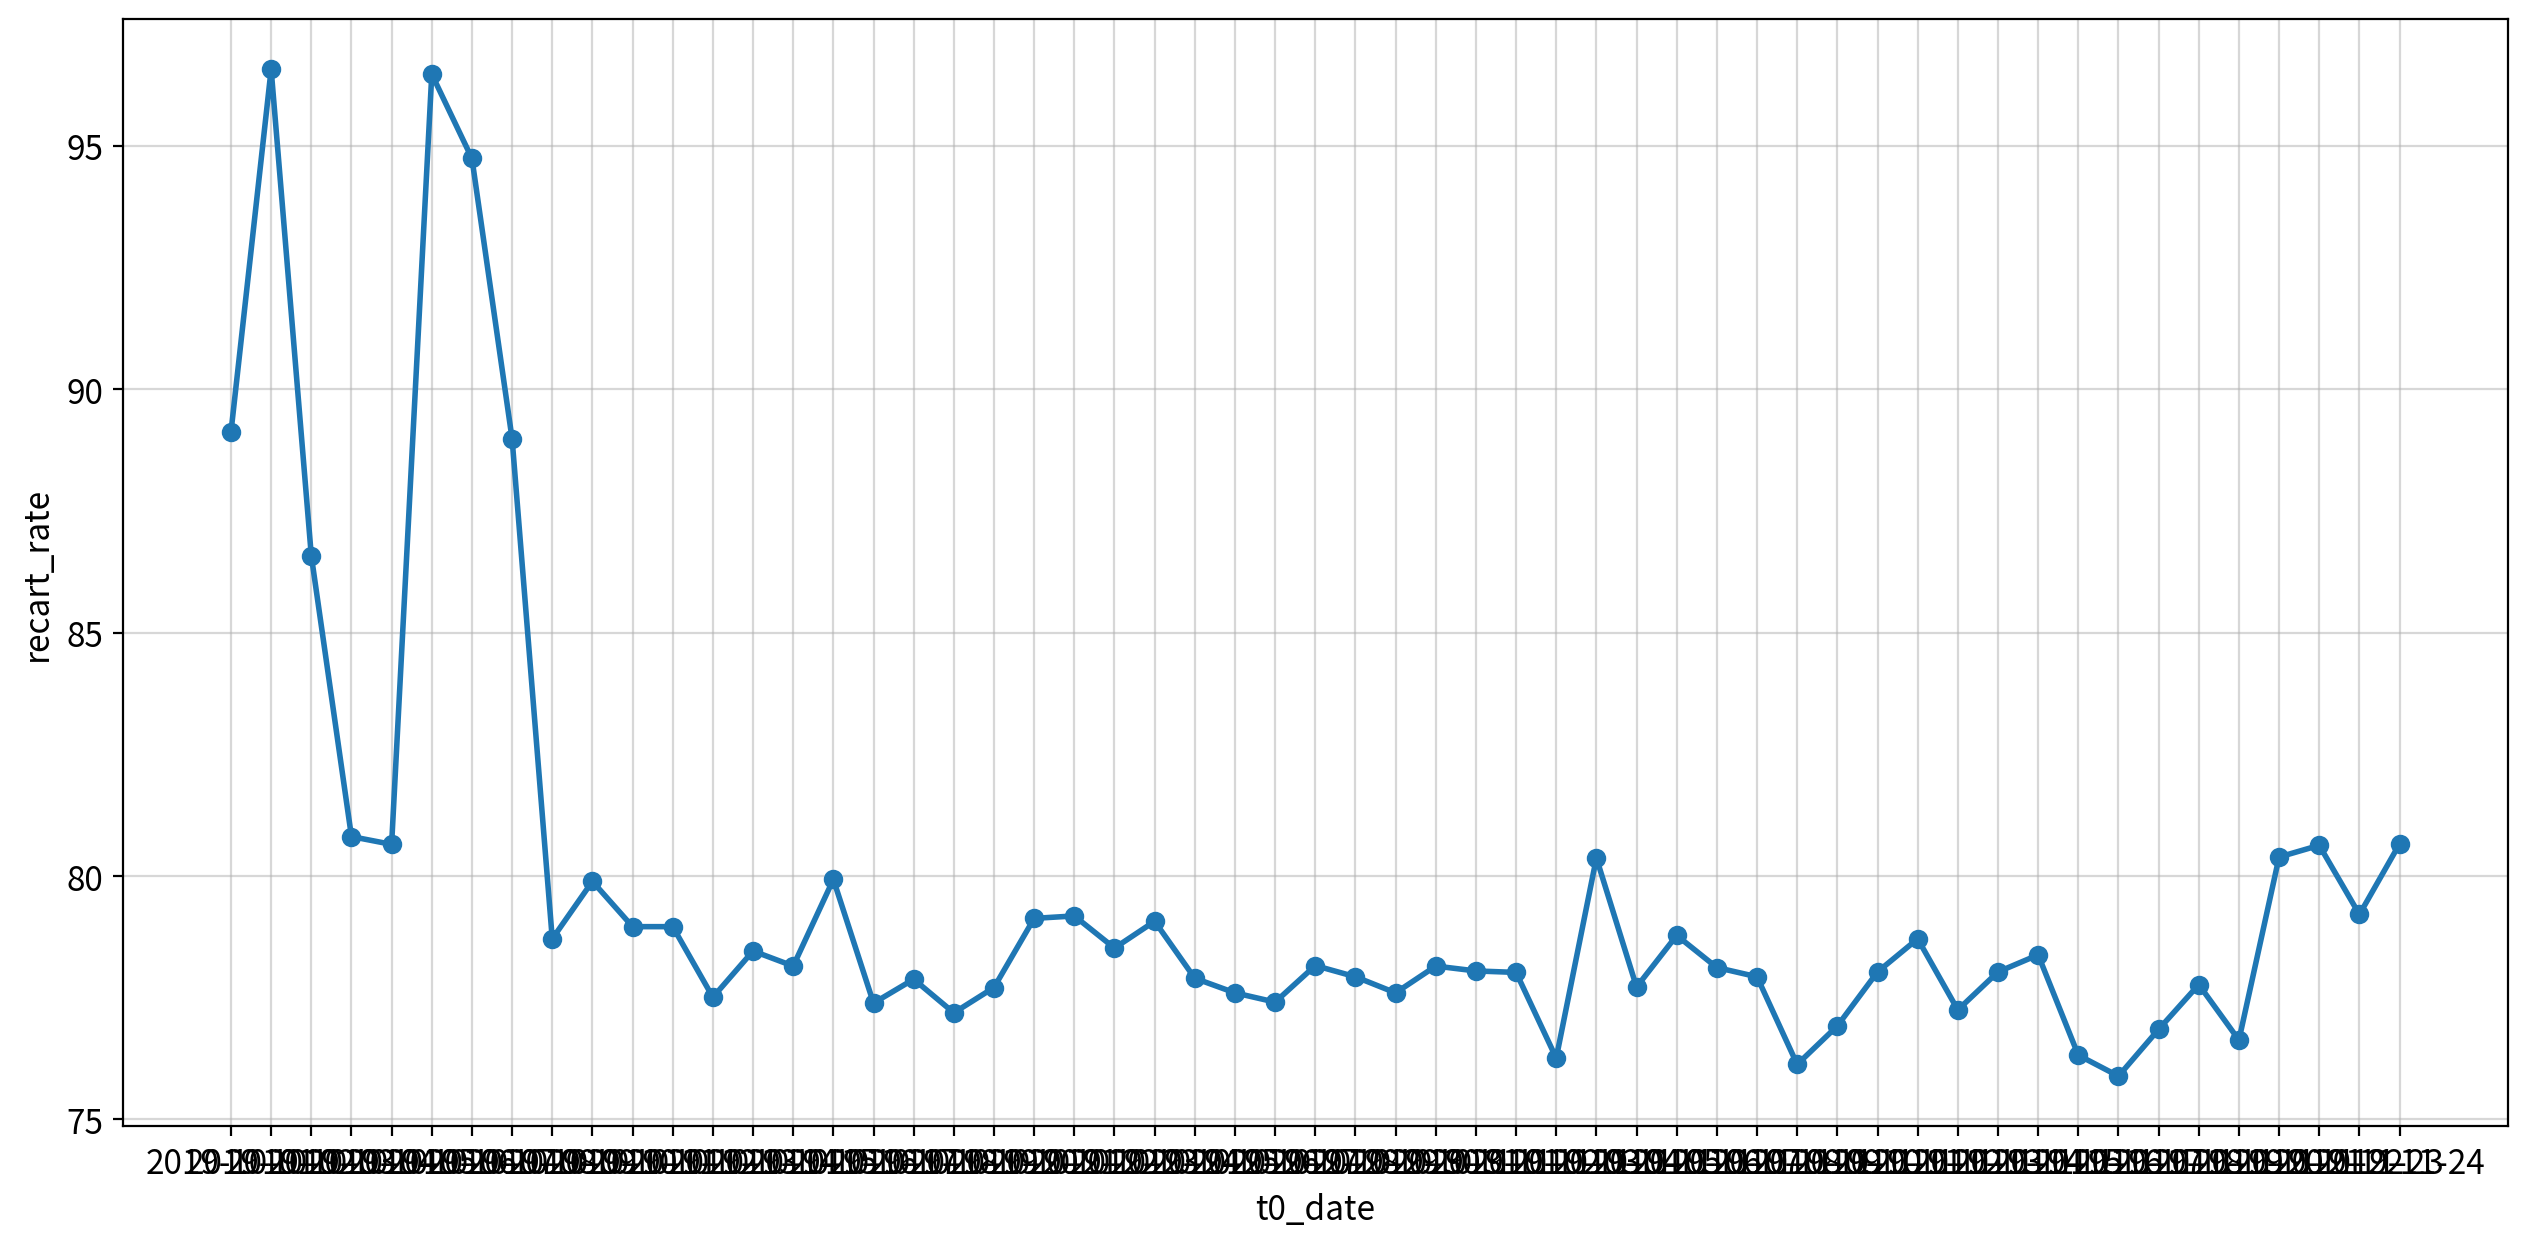

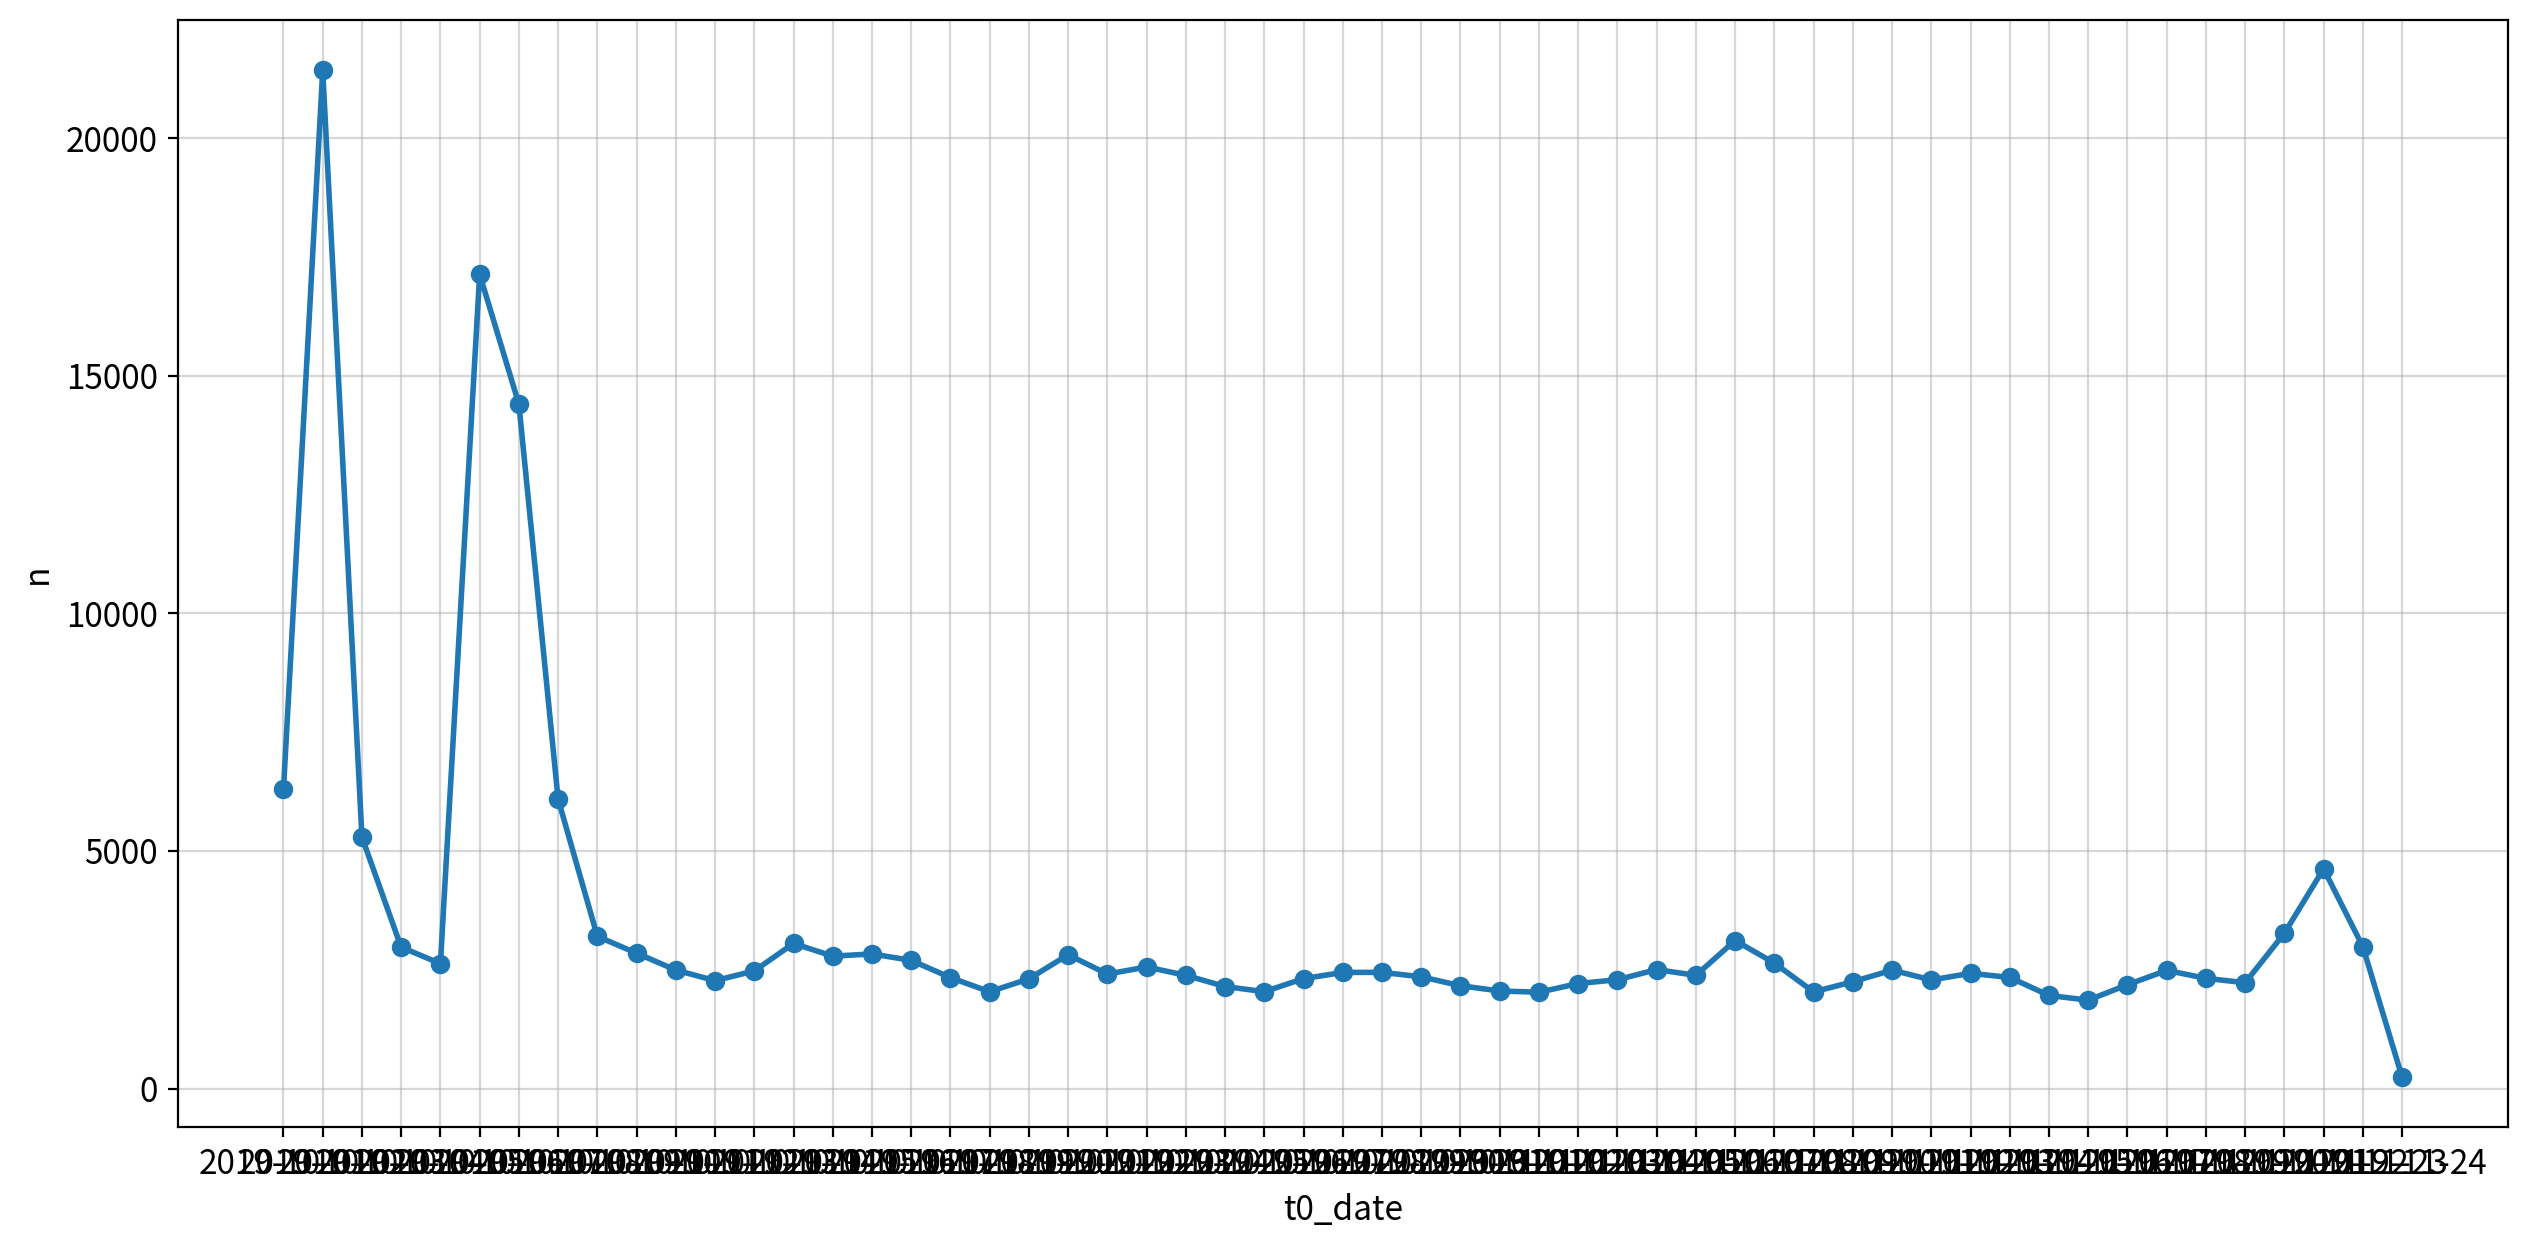

In [24]:
# ---------- #F. 그림 ----------
my_plot.lineplot(data=coh, x="t0_date", y="recart_rate", marker="o")   # 핵심
my_plot.lineplot(data=coh, x="t0_date", y="n",           marker="o")   # 기준선

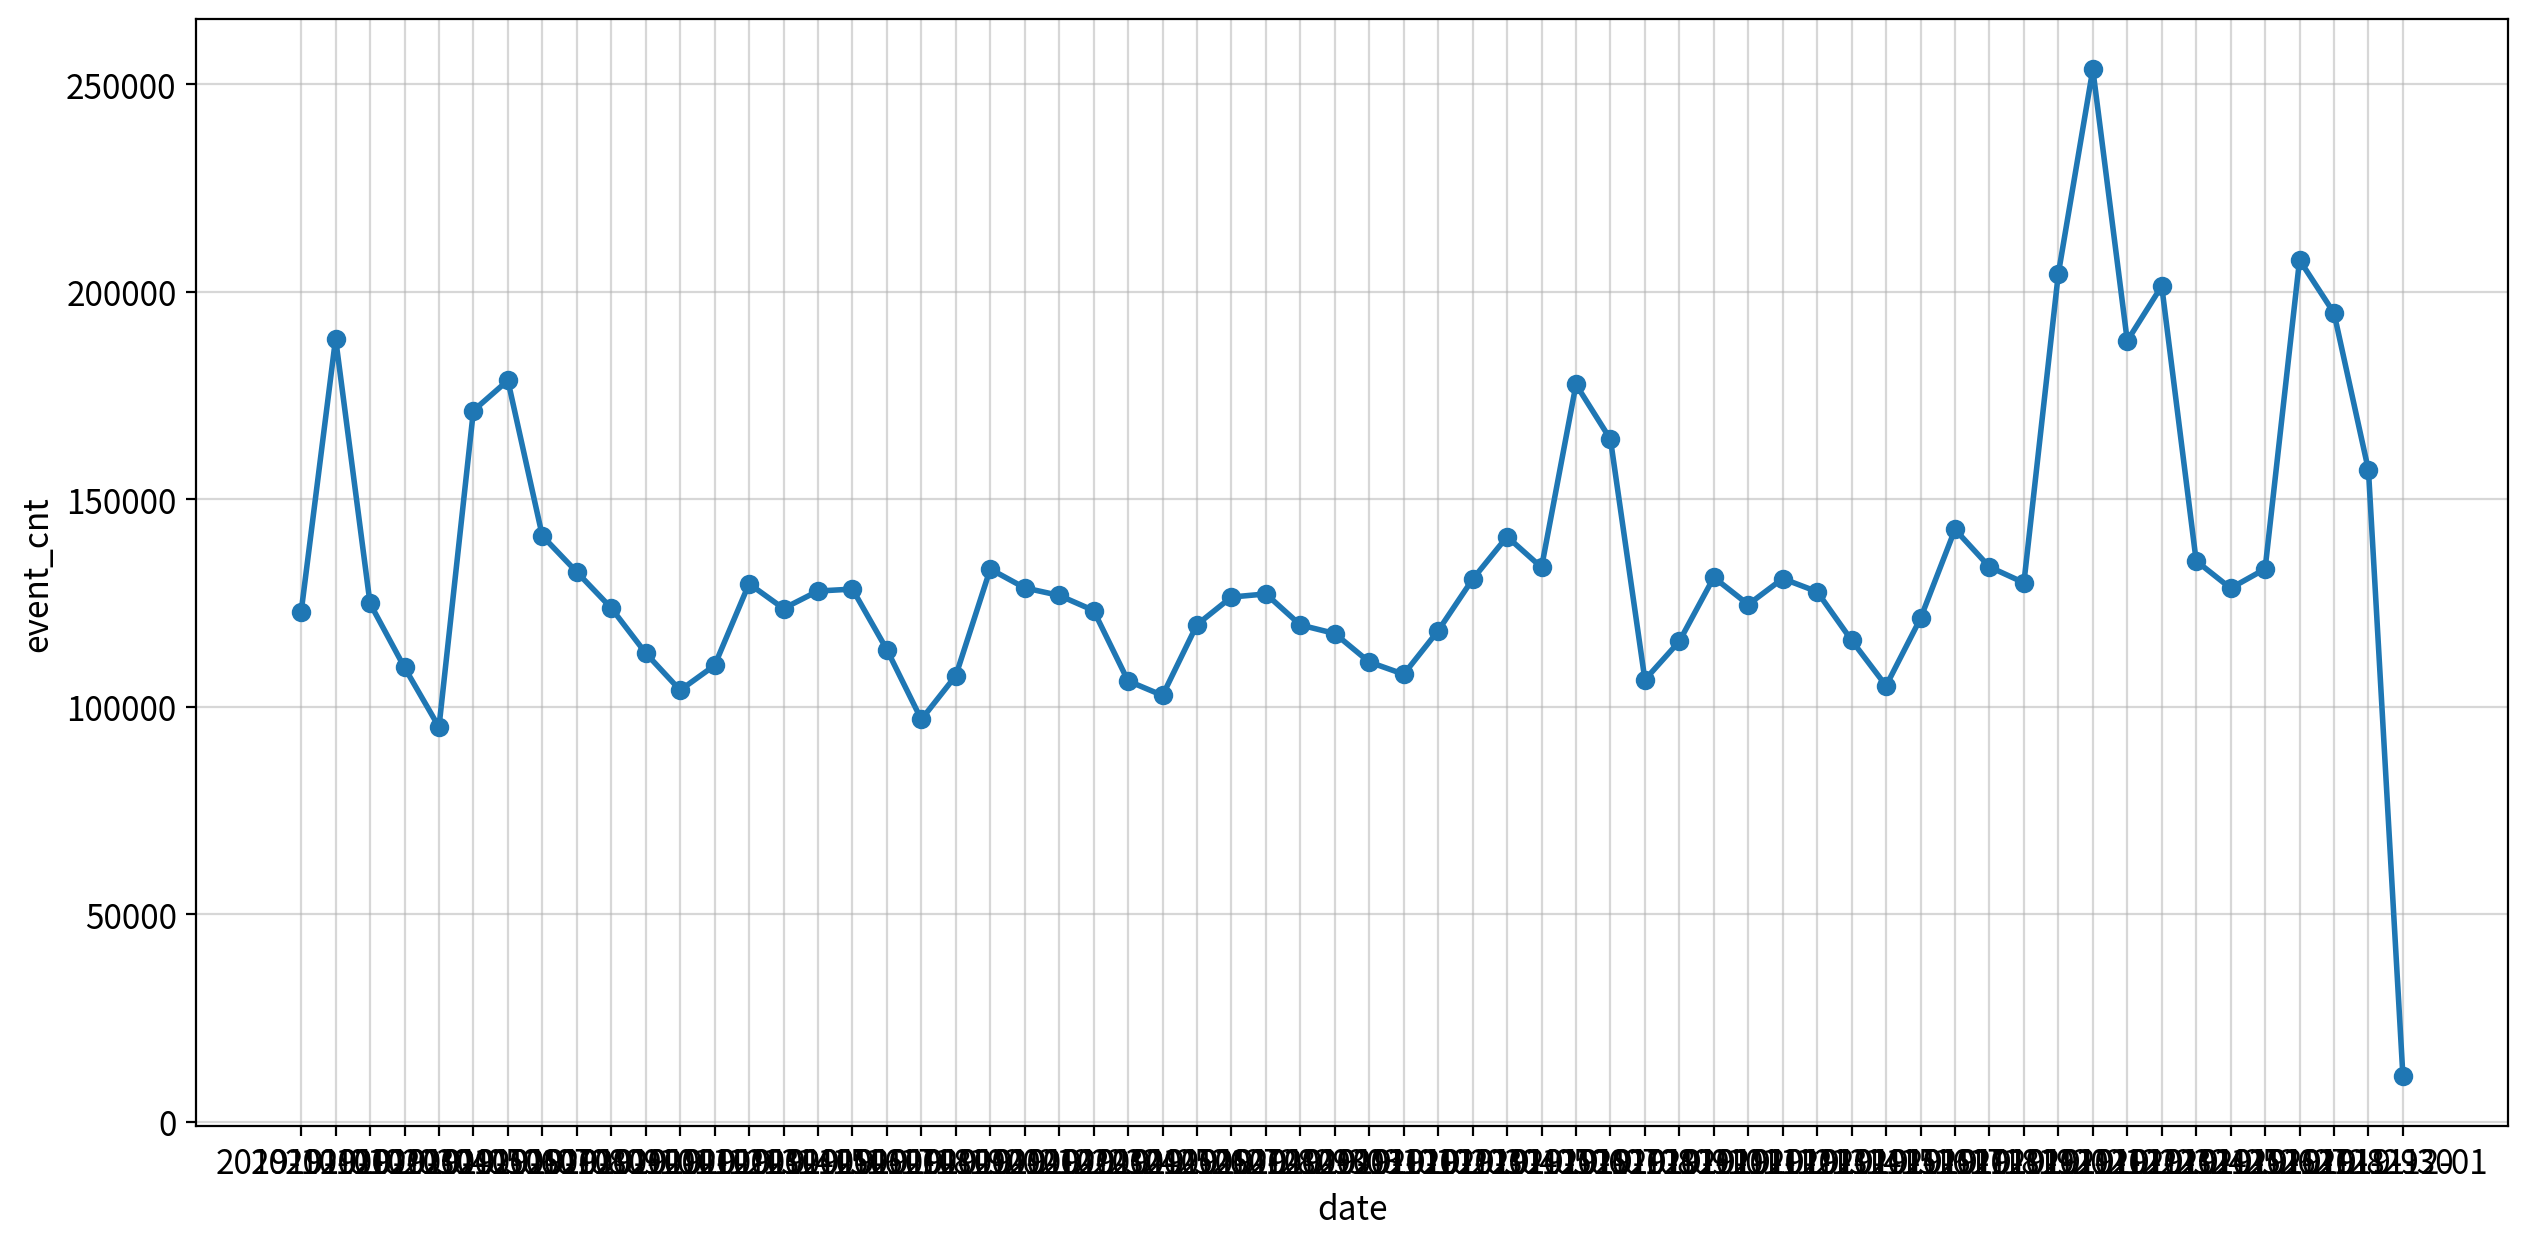

In [25]:
# ---------- #G. 참고: 일별 전체 트래픽 (교란 확인용) ----------
log["date"] = log["event_time"].dt.date.astype(str)
traf = log.groupby("date").size().reset_index()
traf.columns = ["date", "event_cnt"]

my_plot.lineplot(data=traf, x="date", y="event_cnt", marker="o")